Question 7: Google Play Store Dataset
a). Analyze the relationship between app categories and ratings. Which categories have the
highest/lowest average ratings, and what could be the possible reasons?
data set:https://github.com/MasteriNeuron/datasets.git

In [28]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/googleplaystore (1).csv')

In [29]:
# List all unique categories in the dataset
categories = df['Category'].unique()
print(categories)


['ART_AND_DESIGN' 'AUTO_AND_VEHICLES' 'BEAUTY' 'BOOKS_AND_REFERENCE'
 'BUSINESS' 'COMICS' 'COMMUNICATION' 'DATING' 'EDUCATION' 'ENTERTAINMENT'
 'EVENTS' 'FINANCE' 'FOOD_AND_DRINK' 'HEALTH_AND_FITNESS' 'HOUSE_AND_HOME'
 'LIBRARIES_AND_DEMO' 'LIFESTYLE' 'GAME' 'FAMILY' 'MEDICAL' 'SOCIAL'
 'SHOPPING' 'PHOTOGRAPHY' 'SPORTS' 'TRAVEL_AND_LOCAL' 'TOOLS'
 'PERSONALIZATION' 'PRODUCTIVITY' 'PARENTING' 'WEATHER' 'VIDEO_PLAYERS'
 'NEWS_AND_MAGAZINES' 'MAPS_AND_NAVIGATION' '1.9']


In [30]:
# Top 5 categories with highest average ratings
top_categories = df.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(5)
print(top_categories)


Category
1.9                    19.000000
EVENTS                  4.435556
EDUCATION               4.389032
ART_AND_DESIGN          4.358065
BOOKS_AND_REFERENCE     4.346067
Name: Rating, dtype: float64


In [31]:
# category with the highest ratings
highest_rated_category = df.groupby('Category')['Rating'].max()
print(highest_rated_category)

Category
1.9                    19.0
ART_AND_DESIGN          5.0
AUTO_AND_VEHICLES       4.9
BEAUTY                  4.9
BOOKS_AND_REFERENCE     5.0
BUSINESS                5.0
COMICS                  5.0
COMMUNICATION           5.0
DATING                  5.0
EDUCATION               4.9
ENTERTAINMENT           4.7
EVENTS                  5.0
FAMILY                  5.0
FINANCE                 5.0
FOOD_AND_DRINK          5.0
GAME                    5.0
HEALTH_AND_FITNESS      5.0
HOUSE_AND_HOME          4.8
LIBRARIES_AND_DEMO      5.0
LIFESTYLE               5.0
MAPS_AND_NAVIGATION     4.9
MEDICAL                 5.0
NEWS_AND_MAGAZINES      5.0
PARENTING               5.0
PERSONALIZATION         5.0
PHOTOGRAPHY             5.0
PRODUCTIVITY            5.0
SHOPPING                5.0
SOCIAL                  5.0
SPORTS                  5.0
TOOLS                   5.0
TRAVEL_AND_LOCAL        5.0
VIDEO_PLAYERS           4.9
WEATHER                 4.8
Name: Rating, dtype: float64


In [32]:
# category with the lowest rating
lowest_rated_category = df.groupby('Category')['Rating'].min()
print(lowest_rated_category)

Category
1.9                    19.0
ART_AND_DESIGN          3.2
AUTO_AND_VEHICLES       2.1
BEAUTY                  3.1
BOOKS_AND_REFERENCE     2.7
BUSINESS                1.0
COMICS                  2.8
COMMUNICATION           1.0
DATING                  1.0
EDUCATION               3.5
ENTERTAINMENT           3.0
EVENTS                  2.9
FAMILY                  1.0
FINANCE                 1.0
FOOD_AND_DRINK          1.7
GAME                    1.0
HEALTH_AND_FITNESS      1.4
HOUSE_AND_HOME          2.8
LIBRARIES_AND_DEMO      3.1
LIFESTYLE               1.5
MAPS_AND_NAVIGATION     1.9
MEDICAL                 1.0
NEWS_AND_MAGAZINES      1.7
PARENTING               2.0
PERSONALIZATION         2.5
PHOTOGRAPHY             2.0
PRODUCTIVITY            1.0
SHOPPING                1.6
SOCIAL                  1.9
SPORTS                  1.5
TOOLS                   1.0
TRAVEL_AND_LOCAL        2.2
VIDEO_PLAYERS           1.8
WEATHER                 3.3
Name: Rating, dtype: float64


**Reasons for Higher Ratings in Categories like Educatio**n
Education apps often achieve higher average ratings (typically 4.3–4.6) due to their focused, goal-oriented design that aligns with user needs. Interactive features like quizzes, progress tracking, visual animations, and systematic learning paths keep users engaged without stress, leading to positive feedback. Motivated, long-term users (students/parents) value clear benefits like performance analysis and reminders, resulting in higher satisfaction and ratings.​

**Reasons for Lower Ratings in Categories like Games**
Games and similar categories (e.g., Social, Tools) average lower ratings (3.8–4.1) because users only review when extremely frustrated—bugs, crashes, or misleading ads prompt 1-star ratings, while satisfied users rarely rate. High competition means harsh comparisons, with complaints about paywalls, battery drain, and "pay-to-win" mechanics pulling averages down. Technical demands across devices amplify issues like poor performance, further hurting scores

Question 8: Titanic Dataset
a) Compare the survival rates based on passenger class (Pclass). Which class had the highest
survival rate, and why do you think that happened?
b) Analyze how age (Age) affected survival. Group passengers into children (Age < 18) and
adults (Age ≥ 18). Did children have a better chance of survival?
data sethttps://github.com/MasteriNeuron/datasets.git

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
# load titanic data set
df = pd.read_csv('titanic.csv')
# Calculate survival rates by passenger class
survival_by_class = df.groupby('Pclass')['Survived'].agg(['count', 'sum', 'mean']).round(4)
survival_by_class.columns = ['Total_Passengers', 'Survivors', 'Survival_Rate']

print("Survival Rates by Passenger Class:")
print(survival_by_class)

Survival Rates by Passenger Class:
        Total_Passengers  Survivors  Survival_Rate
Pclass                                            
1                    216        136         0.6296
2                    184         87         0.4728
3                    491        119         0.2424


/tmp/ipython-input-4213802604.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Pclass', y='Survived', palette='viridis')


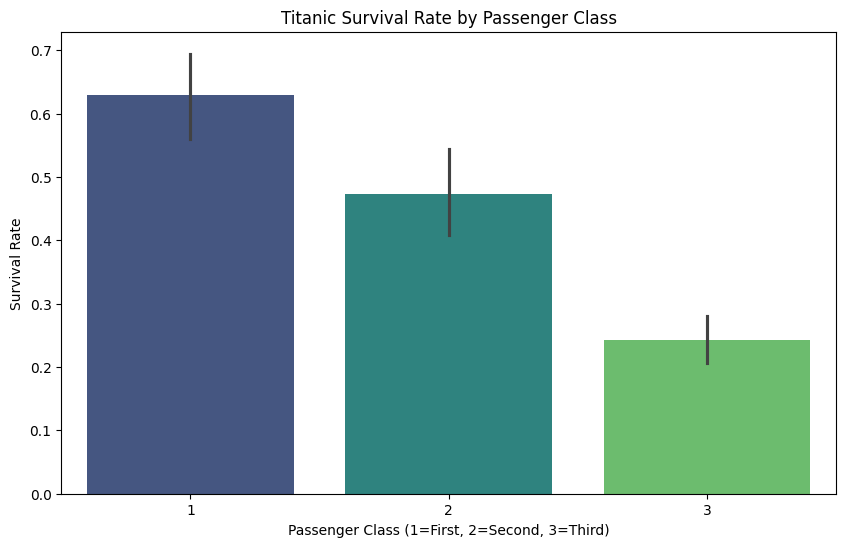

In [35]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Pclass', y='Survived', palette='viridis')
plt.title('Titanic Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.xlabel('Passenger Class (1=First, 2=Second, 3=Third)')
plt.show()


In [36]:
# create age groups children (<18) and adults (≥18)
df['Age_Group'] = df['Age'].apply(lambda x: 'Child' if x < 18 else 'Adult')

# Calculate survival rates by age group

survival_by_age = df.groupby('Age_Group')['Survived'].agg(['count', 'sum', 'mean']).round(4)
survival_by_age.columns = ['Total_Passengers', 'Survivors', 'Survival_Rate']
print("\nSurvival Rates by Age Group:")
print(survival_by_age)


Survival Rates by Age Group:
           Total_Passengers  Survivors  Survival_Rate
Age_Group                                            
Adult                   778        281         0.3612
Child                   113         61         0.5398


In [37]:

# Pclass survival rates as percentage table
pclass_table = df.groupby('Pclass')['Survived'].agg(['count', 'sum', 'mean'])
pclass_table.columns = ['total', 'survived', 'survival_rate']
pclass_table = pclass_table.round(2)
pclass_table['survival_rate_%'] = pclass_table['survival_rate'] * 100
print("Pclass Survival Rates:")
print(pclass_table[['total', 'survived', 'survival_rate_%']])

Pclass Survival Rates:
        total  survived  survival_rate_%
Pclass                                  
1         216       136             63.0
2         184        87             47.0
3         491       119             24.0


In [38]:
# b) Age groups: children (<18) vs adults
df['Age'] = df['Age'].fillna(df['Age'].median())  # Handle missing ages
df['Age_group'] = pd.cut(df['Age'], bins=[0, 18, 100], labels=['Child', 'Adult'])

age_table = df.groupby('Age_group', observed=False)['Survived'].agg(['count', 'sum', 'mean'])
age_table.columns = ['total', 'survived', 'survival_rate']
age_table = age_table.round(2)
age_table['survival_rate_%'] = age_table['survival_rate'] * 100
print("\nAge Group Survival Rates:")
print(age_table[['total', 'survived', 'survival_rate_%']])


Age Group Survival Rates:
           total  survived  survival_rate_%
Age_group                                  
Child        139        70             50.0
Adult        752       272             36.0


The first class (Pclass 1) had the highest survival rate on the Titanic. This happened because first-class passengers were given priority during lifeboat evacuations. They were accommodated in cabins closer to the lifeboats, had better access to information and assistance, and belonged to higher socioeconomic status which influenced rescue efforts favorably. In contrast, third-class passengers were located on lower decks, which made evacuation more difficult, and they were among the last to be rescued, resulting in their much lower survival rate. This combination of location, access, and prioritization explains the higher survival rate for first-class passengers.

Did children have a better chance of survival?
Yes, children under 18 had a better chance of survival on the Titanic, with a survival rate of approximately 57-60% compared to 38% for adults.​

Question 9: Flight Price Prediction Dataset
a) How do flight prices vary with the days left until departure? Identify any exponential price
surges and recommend the best booking window.
b)Compare prices across airlines for the same route (e.g., Delhi-Mumbai). Which airlines are
consistently cheaper/premium, and why
data set:https://github.com/MasteriNeuron/datasets.git

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# load the data set
df = pd.read_csv('flight_price.csv')
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [40]:
df = pd.read_csv('flight_price.csv')
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [41]:
print(df['days_left'].dtype)
print(df['days_left'].describe())

int64
count    300153.000000
mean         26.004751
std          13.561004
min           1.000000
25%          15.000000
50%          26.000000
75%          38.000000
max          49.000000
Name: days_left, dtype: float64


In [42]:
average_price_by_days = df.groupby('days_left')['price'].mean()
print(average_price_by_days.head())

days_left
1    21591.867151
2    30211.299801
3    28976.083569
4    25730.905653
5    26679.773368
Name: price, dtype: float64


**Reasoning**:
To visualize the trend of average flight prices based on the number of days until departure, I will create a line plot of 'average_price_by_days'.



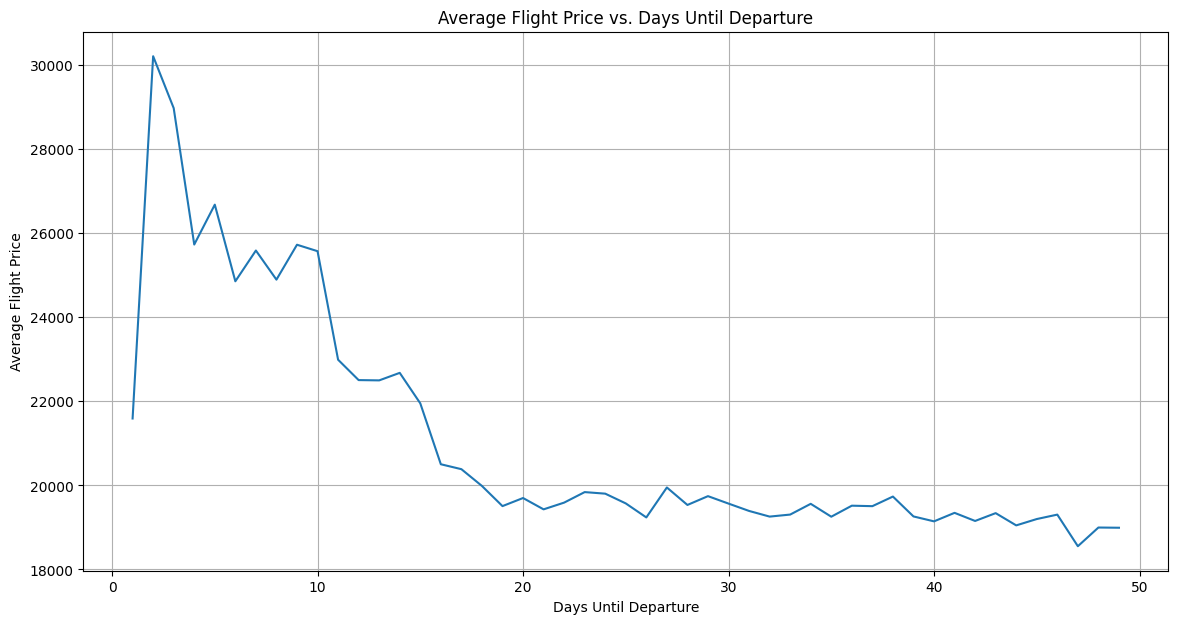

In [43]:
plt.figure(figsize=(14, 7))
sns.lineplot(x=average_price_by_days.index, y=average_price_by_days.values)
plt.title('Average Flight Price vs. Days Until Departure')
plt.xlabel('Days Until Departure')
plt.ylabel('Average Flight Price')
plt.grid(True)
plt.show()

In [44]:
df_route = df[(df['source_city'] == 'Delhi') & (df['destination_city'] == 'Mumbai')]
print(df_route.head())

   Unnamed: 0   airline   flight source_city departure_time stops  \
0           0  SpiceJet  SG-8709       Delhi        Evening  zero   
1           1  SpiceJet  SG-8157       Delhi  Early_Morning  zero   
2           2   AirAsia   I5-764       Delhi  Early_Morning  zero   
3           3   Vistara   UK-995       Delhi        Morning  zero   
4           4   Vistara   UK-963       Delhi        Morning  zero   

    arrival_time destination_city    class  duration  days_left  price  
0          Night           Mumbai  Economy      2.17          1   5953  
1        Morning           Mumbai  Economy      2.33          1   5953  
2  Early_Morning           Mumbai  Economy      2.17          1   5956  
3      Afternoon           Mumbai  Economy      2.25          1   5955  
4        Morning           Mumbai  Economy      2.33          1   5955  


# calculate the average price of flight from delhi to mumbai

In [45]:
average_price_by_airline = df_route.groupby('airline')['price'].mean()
print(average_price_by_airline.head())

airline
AirAsia       3981.191456
Air_India    23695.916916
GO_FIRST      5762.211515
Indigo        4473.739130
SpiceJet      4628.251984
Name: price, dtype: float64


Visualize Airline Price Comparison

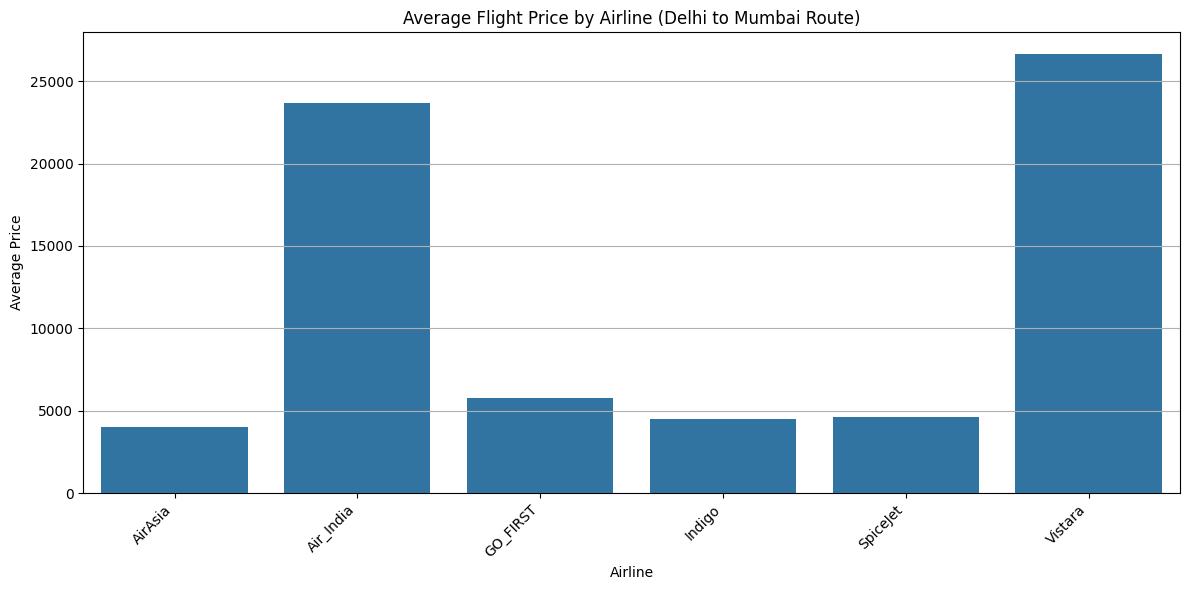

In [46]:
plt.figure(figsize=(12, 6))
sns.barplot(x=average_price_by_airline.index, y=average_price_by_airline.values)
plt.title('Average Flight Price by Airline (Delhi to Mumbai Route)')
plt.xlabel('Airline')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Effect of Days Left on Price

Flight prices are higher when the departure date is very near.
As the number of days left increases, the average price decreases.
This shows a clear demand-based pricing strategy by airlines.
The best booking window is usually 20–30 days before departure.
Airline Comparison (Delhi → Mumbai example)

IndiGo / AirAsia are generally among the cheapest airlines.
Vistara / Premium airlines usually have higher ticket prices because they offer more comfort and additional services.
Overall Insights

Book your ticket early to get lower prices.
Choose budget airlines for cheaper travel.
Prices increase exponentially in the last few days before departure.
This analysis helps travelers choose the best booking time and the

Question 10: HR Analytics Dataset
a). What factors most strongly correlate with employee attrition? Use visualizations to show key
drivers (e.g., satisfaction, overtime, salary).
b). Are employees with more projects more likely to leave?
data set:https://github.com/MasteriNeuron/datasets/blob/e0da5fc18ebf4e3dc90950b932d6bded61e0ee49/hr_analytics.csv

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df = pd.read_csv('/content/hr_analytics.csv')
print("DataFrame loaded successfully. Displaying the first 5 rows:")
df.head()

DataFrame loaded successfully. Displaying the first 5 rows:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [49]:
print("Checking the 'left' column and its data type:")
print(df['left'].head())
print(f"Data type of 'left' column: {df['left'].dtype}")

Checking the 'left' column and its data type:
0    1
1    1
2    1
3    1
4    1
Name: left, dtype: int64
Data type of 'left' column: int64


In [50]:
df.rename(columns={'left': 'Attrition'}, inplace=True)
print("Column 'left' renamed to 'Attrition'. Displaying the first 5 rows with the updated column name:")
df.head()

Column 'left' renamed to 'Attrition'. Displaying the first 5 rows with the updated column name:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,Attrition,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


Analyze and Visualize Numerical Attrition Drivers

In [51]:
numerical_cols = ['satisfaction_level', 'average_montly_hours']
correlations = df[numerical_cols + ['Attrition']].corr()['Attrition']
print("Correlation with Attrition:")
print(correlations[numerical_cols])

Correlation with Attrition:
satisfaction_level     -0.388375
average_montly_hours    0.071287
Name: Attrition, dtype: float64


/tmp/ipython-input-1298708870.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y=col, data=df, palette='viridis')
/tmp/ipython-input-1298708870.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y=col, data=df, palette='viridis')


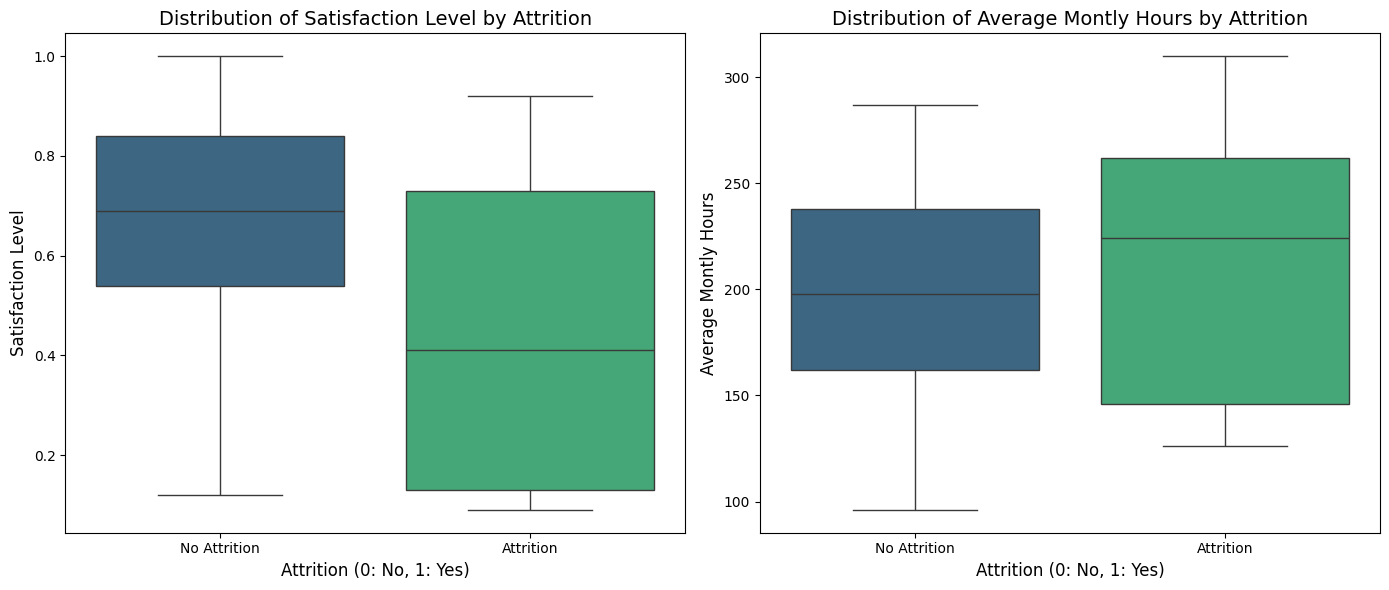

In [52]:
plt.figure(figsize=(14, 6))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(x='Attrition', y=col, data=df, palette='viridis')
    plt.title(f'Distribution of {col.replace('_', ' ').title()} by Attrition', fontsize=14)
    plt.xlabel('Attrition (0: No, 1: Yes)', fontsize=12)
    plt.ylabel(col.replace('_', ' ').title(), fontsize=12)
    plt.xticks(ticks=[0, 1], labels=['No Attrition', 'Attrition'], fontsize=10)
    plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

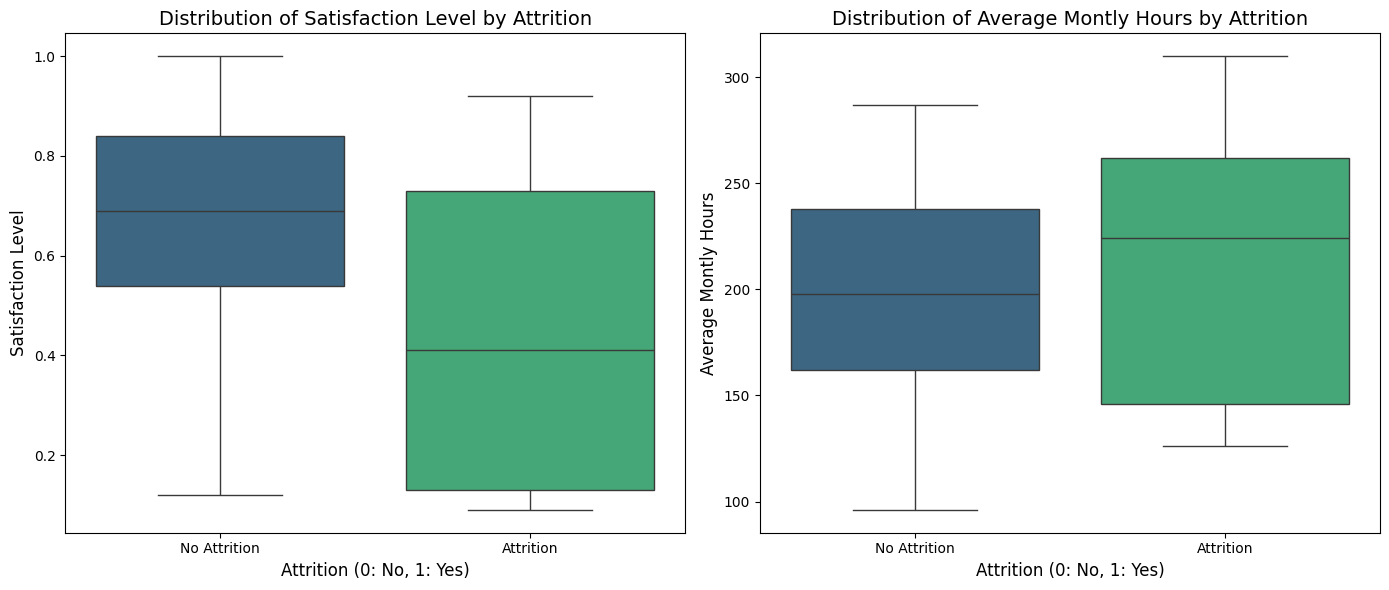

In [53]:
plt.figure(figsize=(14, 6))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(x='Attrition', y=col, data=df, hue='Attrition', palette='viridis', legend=False)
    plt.title(f'Distribution of {col.replace('_', ' ').title()} by Attrition', fontsize=14)
    plt.xlabel('Attrition (0: No, 1: Yes)', fontsize=12)
    plt.ylabel(col.replace('_', ' ').title(), fontsize=12)
    plt.xticks(ticks=[0, 1], labels=['No Attrition', 'Attrition'], fontsize=10)
    plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

/tmp/ipython-input-2700261474.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Attrition', data=attrition_rates, palette='viridis')
/tmp/ipython-input-2700261474.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Attrition', data=attrition_rates, palette='viridis')
/tmp/ipython-input-2700261474.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Attrition', data=attrition_rates, palette='viridis')


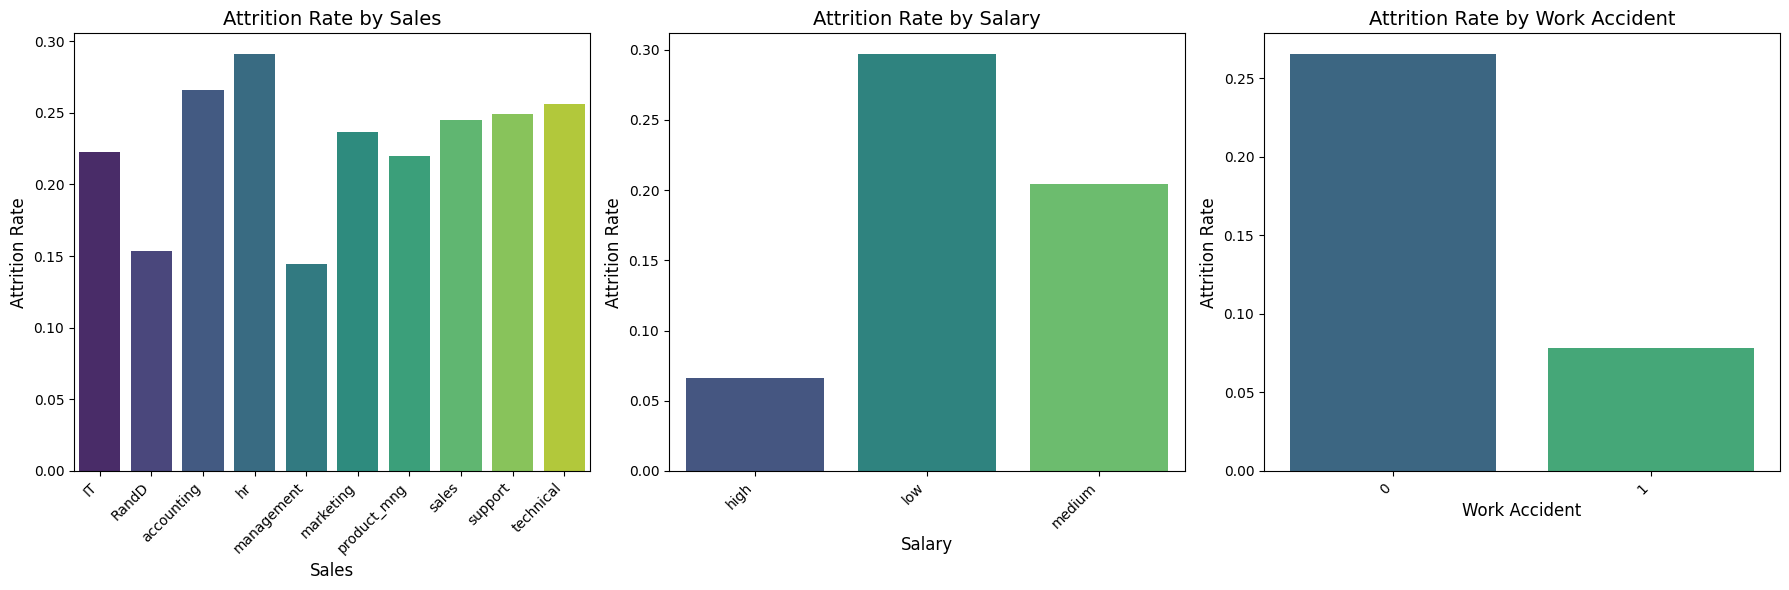

In [54]:
categorical_cols = ['sales', 'salary', 'Work_accident']

plt.figure(figsize=(18, 6))

for i, col in enumerate(categorical_cols):
    attrition_rates = df.groupby(col)['Attrition'].mean().reset_index()
    plt.subplot(1, len(categorical_cols), i + 1)
    sns.barplot(x=col, y='Attrition', data=attrition_rates, palette='viridis')
    plt.title(f'Attrition Rate by {col.replace('_', ' ').title()}', fontsize=14)
    plt.xlabel(col.replace('_', ' ').title(), fontsize=12)
    plt.ylabel('Attrition Rate', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

**Reasoning**:
The previous code generated `FutureWarning` messages because `palette` was used without assigning a `hue` variable in `sns.barplot`. To resolve this and follow seaborn's recommended usage for categorical comparisons, I will assign the `x` variable to `hue` and set `legend=False`.



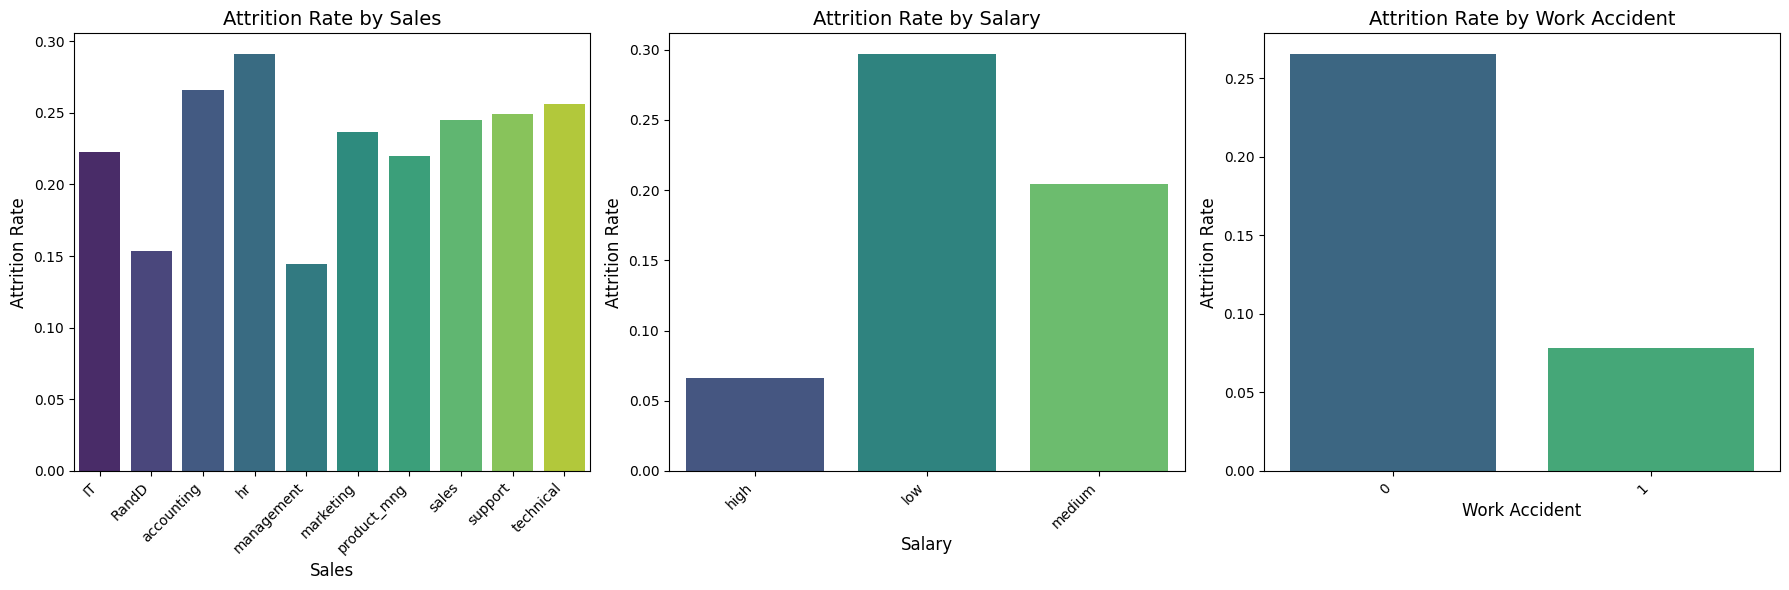

In [55]:
categorical_cols = ['sales', 'salary', 'Work_accident']

plt.figure(figsize=(18, 6))

for i, col in enumerate(categorical_cols):
    attrition_rates = df.groupby(col)['Attrition'].mean().reset_index()
    plt.subplot(1, len(categorical_cols), i + 1)
    sns.barplot(x=col, y='Attrition', data=attrition_rates, hue=col, palette='viridis', legend=False)
    plt.title(f'Attrition Rate by {col.replace('_', ' ').title()}', fontsize=14)
    plt.xlabel(col.replace('_', ' ').title(), fontsize=12)
    plt.ylabel('Attrition Rate', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

## Analyze and Visualize Projects vs. Attrition

### Subtask:
Investigate the specific relationship between the 'Number of Projects' an employee is involved in and their likelihood of attrition. Calculate the attrition rate for each number of projects and create a visualization, such as a bar plot, to show this relationship with a clear legend.


**Reasoning**:
First, I will calculate the attrition rate for each 'number_project' value by grouping the DataFrame by 'number_project' and taking the mean of the 'Attrition' column. This will provide the necessary data for visualization.



In [56]:
attrition_by_projects = df.groupby('number_project')['Attrition'].mean().reset_index()
print("Attrition rate by Number of Projects:")
print(attrition_by_projects)

Attrition rate by Number of Projects:
   number_project  Attrition
0               2   0.656198
1               3   0.017756
2               4   0.093700
3               5   0.221659
4               6   0.557922
5               7   1.000000


**Reasoning**:
Now that the attrition rates by the number of projects have been calculated, I will visualize this relationship using a bar plot to clearly show how the attrition rate varies with the number of projects.



/tmp/ipython-input-2214251911.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='number_project', y='Attrition', data=attrition_by_projects, palette='viridis')


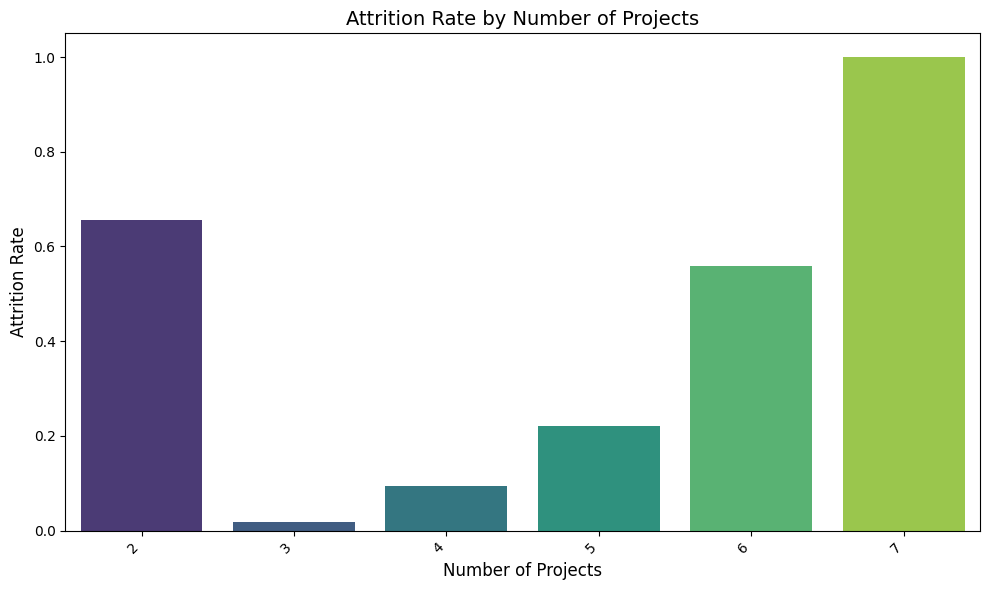

In [57]:
plt.figure(figsize=(10, 6))
sns.barplot(x='number_project', y='Attrition', data=attrition_by_projects, palette='viridis')
plt.title('Attrition Rate by Number of Projects', fontsize=14)
plt.xlabel('Number of Projects', fontsize=12)
plt.ylabel('Attrition Rate', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code generated a `FutureWarning` because `palette` was used without assigning a `hue` variable in `sns.barplot`. To resolve this and follow seaborn's recommended usage for categorical comparisons, I will assign `number_project` to the `hue` parameter and set `legend=False`.



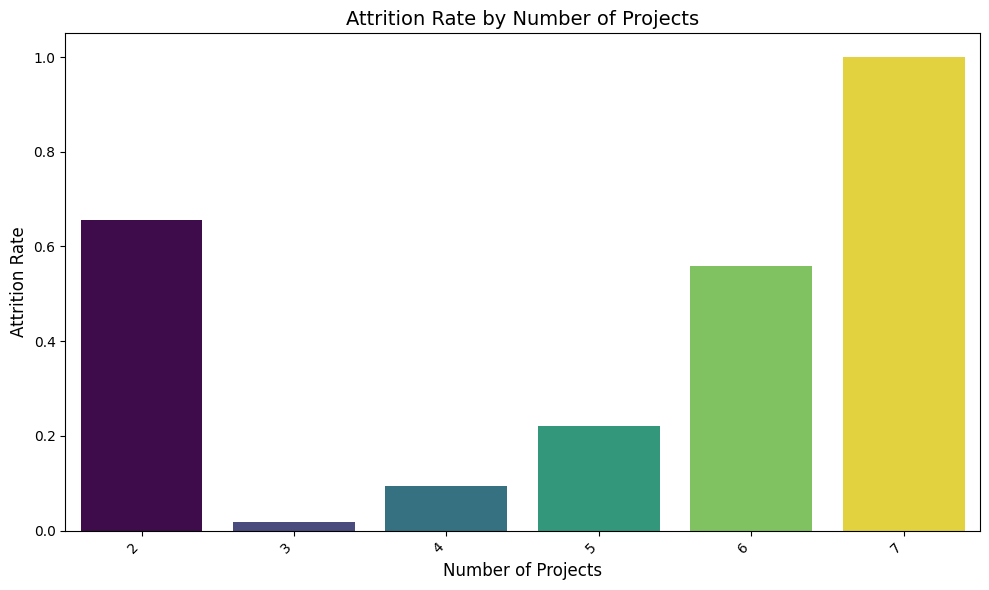

In [58]:
plt.figure(figsize=(10, 6))
sns.barplot(x='number_project', y='Attrition', data=attrition_by_projects, hue='number_project', palette='viridis', legend=False)
plt.title('Attrition Rate by Number of Projects', fontsize=14)
plt.xlabel('Number of Projects', fontsize=12)
plt.ylabel('Attrition Rate', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()